Env: conda create -n driving_distance python=3.12.11
conda init bash
source ~/.bashrc
conda activate driving_distance\

conda install -c conda-forge fsspec s3fs=2023.6.0 pyarrow tqdm scipy aiohttp \

conda install -c conda-forge pandas numpy boto3 requests geopy ipython \

conda install -c conda-forge xlsxwriter openpyxl matplotlib seaborn sklearn\

In [1]:
import os
import numpy as np
import pandas as pd
import boto3
import time
import sys
cwd = os.getcwd()
print(cwd)


/home/sagemaker-user/CAPE_V4_V5_PERFORMANCE


###  PRAC_HIS_PIF_073125.csv


In [2]:

# import all the data from V4
bucket_name = 'pr-home-datascience'
prefix = 'Projects/AdHoc/InternProjects/2025/2025FallCapeV5_vs_V4_performance_analysis/'
s3 = boto3.client('s3')

response = s3.list_objects_v2(Bucket=bucket_name, Prefix=prefix)

# Read V4 data 
if 'Contents' in response:
    files = [obj['Key'] for obj in response['Contents'] if obj['Key'].endswith('25.csv')]
else:
    print("No files found.")

# next is to read them all into pandas dataframes
df4 = []
for file in files:
    path = 's3://'+ bucket_name + '/' + file
    print('Reading from the file ', file)
    df = pd.read_csv(path, sep = ',', low_memory=False)
    df4.append(df)


# final step is to catch into one dataframe
if df4:
    prac_his_pif = pd.concat(df4, ignore_index=True)
    print('Merged data in Version 4 of ', len(df4), ' files successfully.')
    print('Now the total rows are ', len(prac_his_pif))
else:
    prac_his_pif = pd.DataFrame()
    print("No files found.")

Reading from the file  Projects/AdHoc/InternProjects/2025/2025FallCapeV5_vs_V4_performance_analysis/PRAC_Historical_PIF_072025_Updated_073125.csv
Reading from the file  Projects/AdHoc/InternProjects/2025/2025FallCapeV5_vs_V4_performance_analysis/PRAC_PIF_052025.csv
Merged data in Version 4 of  2  files successfully.
Now the total rows are  2151889


Do some quick examination

In [3]:
prac_his_pif.describe()

# prac_his_pif[0:5]
print(f'There are {len(prac_his_pif)} data in total.')
print(f'There are {len(prac_his_pif.columns)} variables.')
print(prac_his_pif.columns)
'''
keywords = 'roof'

key_columns = [col for col in prac_his_pif.columns if keywords in col.lower()]
print('There are ', len(key_columns), ' variables contains ' + keywords + '.')
print('They are ', key_columns)
# print(prac_his_pif[key_columns].describe())
'''
print(prac_his_pif.head())

There are 2151889 data in total.
There are 19 variables.
Index(['pol_num', 'orgl_pol_eff_dt', 'address1', 'property_address', 'city',
       'state', 'zipcode', 'cape_run_dt', 'POL_NUM', 'ORGL_POL_EFF_DT',
       'ADDRESS1', 'HOUSE_NUMBER', 'STREET_NAME', 'STREET_TYPE',
       'PROPERTY_ADDRESS', 'CITY', 'STATE', 'ZIPCODE', 'COUNTY'],
      dtype='object')
              pol_num orgl_pol_eff_dt                            address1  \
0  BH_000000001536627      2018-07-01  64 W UNIVERSITY ST ALFRED NY 14802   
1  BH_000000001536627      2018-07-01  64 W UNIVERSITY ST ALFRED NY 14802   
2  BH_000000001536627      2018-07-01  64 W UNIVERSITY ST ALFRED NY 14802   
3  BH_000000001536627      2018-07-01  64 W UNIVERSITY ST ALFRED NY 14802   
4  BH_000000001536627      2018-07-01  64 W UNIVERSITY ST ALFRED NY 14802   

     property_address    city state  zipcode cape_run_dt POL_NUM  \
0  64 W UNIVERSITY ST  ALFRED    NY  14802.0  2018-06-01     NaN   
1  64 W UNIVERSITY ST  ALFRED    NY  14802

In [4]:
vars = ['pol_num', 'address1', 'property_address']
for var in vars:
    unique_count = prac_his_pif[var].nunique()
    print("Number of unique " + var + ':', unique_count)
    print(f"Five years of unique {var} gives {5 * unique_count}")

Number of unique pol_num: 421962
Five years of unique pol_num gives 2109810
Number of unique address1: 401492
Five years of unique address1 gives 2007460
Number of unique property_address: 390233
Five years of unique property_address gives 1951165


### PRH_UWLookback_processed_combinev4v5.csv



In [5]:

# import all the data from May data
bucket_name = 'pr-home-datascience'
prefix = 'Projects/AdHoc/InternProjects/2025/2025FallCapeV5_vs_V4_performance_analysis/'
s3 = boto3.client('s3')

response = s3.list_objects_v2(Bucket=bucket_name, Prefix=prefix)

# Read May data
if 'Contents' in response:
    files = [obj['Key'] for obj in response['Contents'] if obj['Key'].endswith('v4v5.csv')]
else:
    print("No files found.")

# next is to read them all into pandas dataframes
df4 = []
for file in files:
    path = 's3://'+ bucket_name + '/' + file
    print('Reading from the file ', file)
    df = pd.read_csv(path, sep = ',', low_memory=False)
    df4.append(df)


# final step is to catch into one dataframe
if df4:
    prh_UWlookback = pd.concat(df4, ignore_index=True)
    print('Merged data in May of ', len(prh_UWlookback), ' files successfully.')
    print('Now the total rows are ', len(prh_UWlookback))
else:
    prh_UWlookback = pd.DataFrame()
    print("No files found.")

Reading from the file  Projects/AdHoc/InternProjects/2025/2025FallCapeV5_vs_V4_performance_analysis/PRH_UWLookback_processed_combinedv4v5.csv


Merged data in Version 4 of  757655  files successfully.
Now the total rows are  757655


In [6]:
prh_UWlookback.describe()

# prh_UWlookback[0:5]
print(f'There are {len(prh_UWlookback)} data in total.')
print(f'There are {len(prh_UWlookback.columns)} variables.')
# print(prh_UWlookback.columns)


There are 757655 data in total.
There are 233 variables.


In [7]:
# Get all v4 and v5 columns
v4_cols = [c for c in prh_UWlookback.columns if c.startswith("v4_")]
v5_cols = [c for c in prh_UWlookback.columns if c.startswith("v5_")]

v4_base = {c.replace("v4_", "") for c in v4_cols}
v5_base = {c.replace("v5_", "") for c in v5_cols}

# Get unique columns only in v5
v5_unique = list(set(v5_base) - set(v4_base))

print("Unique variables only in v5:")
print(" ".join("v5_" + v for v in v5_unique))
print("Count:", len(v5_unique))

v4_unique = list(set(v4_base) - set(v5_base))
print("Unique variables only in v4:")
print(" ".join("v4_" + v for v in v4_unique))
print("Count:", len(v4_unique))


v4_roof_base = {c for c in v4_base if "roof" in c.lower()}
v5_roof_base = {c for c in v5_base if "roof" in c.lower()}

# Intersection: common in both v4 and v5
common_roof = v4_roof_base & v5_roof_base

# Unique to v4 / v5
v4_only_roof = v4_roof_base - v5_roof_base
v5_only_roof = v5_roof_base - v4_roof_base

print("Common roof vars (count={}):".format(len(common_roof)), common_roof)
print("Only in v4 (count={}):".format(len(v4_only_roof)), v4_only_roof)
print("Only in v5 (count={}):".format(len(v5_only_roof)), v5_only_roof)

Unique variables only in v5:
v5_cape_roof_missing_or_peeling_material_end_date v5_cape_roof_structural_damage_start_date v5_cape_roof_material_degradation_end_date v5_cape_roof_condition_reasons_end_date v5_cape_roof_structural_damage_confidence v5_cape_roof_sealing_end_date v5_cape_roof_missing_or_peeling_material_start_date v5_cape_roof_structural_damage_end_date v5_cape_roof_effluent_runoff_end_date v5_cape_roof_ponding_end_date v5_cape_roof_structural_damage v5_cape_roof_missing_or_peeling_material_image_url v5_cape_roof_rusting_end_date v5_cape_roof_effluent_runoff_start_date v5_cape_roof_missing_or_peeling_material v5_cape_roof_sealing_image_url v5_cape_roof_ponding_start_date v5_cape_roof_rusting_image_url v5_cape_roof_missing_or_peeling_material_confidence v5_cape_roof_sealing_image_source v5_cape_roof_sealing v5_cape_roof_sealing_start_date v5_cape_roof_condition_rating_end_date v5_cape_roof_sealing_confidence v5_cape_roof_condition_rating_start_date v5_cape_roof_condition_rea

Quick check the variable names

In [8]:

keywords = 'dt'

key_columns = [col for col in prh_UWlookback.columns if keywords in col.lower()]
print('There are ', len(key_columns), ' variables contains ' + keywords + '.')
print("\n".join(key_columns))
# print(prh_UWlookback[key_columns].describe())


keywords = 'run_'

key_columns = [col for col in prh_UWlookback.columns if keywords in col.lower()]
print('There are ', len(key_columns), ' variables contains ' + keywords + '.')
print("\n".join(key_columns))
# print(prh_UWlookback[key_columns].describe())

keywords = '_roof_condition_rating'

key_columns = [col for col in prh_UWlookback.columns if keywords in col.lower()]
print('There are ', len(key_columns), ' variables contains ' + keywords + '.')
print("\n".join(key_columns))
# print(prh_UWlookback[key_columns].describe())




There are  2  variables contains dt.
v5_ORGL_POL_EFF_DT
v4_ORGL_POL_EFF_DT
There are  0  variables contains run_.

There are  21  variables contains _roof_condition_rating.
v5_cape_accessory_structure_roof_condition_rating
v5_cape_accessory_structure_roof_condition_rating_confidence
v5_cape_accessory_structure_roof_condition_rating_date
v5_cape_accessory_structure_roof_condition_rating_image_source
v5_cape_accessory_structure_roof_condition_rating_image_url
v5_cape_roof_condition_rating
v5_cape_roof_condition_rating_confidence
v5_cape_roof_condition_rating_start_date
v5_cape_roof_condition_rating_end_date
v5_cape_roof_condition_rating_image_source
v5_cape_roof_condition_rating_image_url
v4_cape_accessory_structure_roof_condition_rating
v4_cape_accessory_structure_roof_condition_rating_confidence
v4_cape_accessory_structure_roof_condition_rating_date
v4_cape_accessory_structure_roof_condition_rating_image_source
v4_cape_accessory_structure_roof_condition_rating_image_url
v4_cape_roof_co

In [9]:
print(prh_UWlookback['v5_cape_roof_condition_rating_end_date'])
print(f'There are unique dates of {prh_UWlookback['v5_EFFECTIVE_DATE'].nunique()}')

0         9/21/2023
1         3/24/2024
2          3/8/2024
3          3/1/2024
4         5/17/2017
            ...    
757650    3/20/2019
757651    3/25/2017
757652    3/25/2017
757653    3/25/2017
757654    3/25/2017
Name: v5_cape_roof_condition_rating_end_date, Length: 757655, dtype: object
There are unique dates of 1827


In [10]:

keywords = 'pol_num'

key_columns = [col for col in prh_UWlookback.columns if keywords in col.lower()]
print('There are ', len(key_columns), ' variables contains ' + keywords + '.')
print('They are ', key_columns)
# print(prh_UWlookback[key_columns].describe())

There are  2  variables contains pol_num.
They are  ['v5_POL_NUM', 'v4_POL_NUM']


In [11]:
print(prh_UWlookback['v5_POL_NUM'].head())
print(prh_UWlookback['v4_POL_NUM'].head())

# 1. Check if they are exactly identical (all values same, including order & NaN positions)
same_all = prh_UWlookback['v5_POL_NUM'].equals(prh_UWlookback['v4_POL_NUM'])
print("Completely identical:", same_all)


0    MAH00002011636
1    MAH00002012432
2    NJH00002027570
3    NYH00002009549
4    NYH00002011357
Name: v5_POL_NUM, dtype: object
0    MAH00002011636
1    MAH00002012432
2    NJH00002027570
3    NYH00002009549
4    NYH00002011357
Name: v4_POL_NUM, dtype: object
Completely identical: True


In [12]:

keywords = 'v4'

key_columns = [col for col in prh_UWlookback.columns if keywords in col.lower()]
print('There are ', len(key_columns), ' variables contains ' + keywords + '.')
print('They are ', key_columns)
# print(prh_UWlookback[key_columns].describe())

keywords = 'v5'

key_columns = [col for col in prh_UWlookback.columns if keywords in col.lower()]
print('There are ', len(key_columns), ' variables contains ' + keywords + '.')
print('They are ', key_columns)
# print(prh_UWlookback[key_columns].describe())


print(prh_UWlookback.head())

There are  109  variables contains v4.
They are  ['v4_Source Row Number', 'v4_cape_response_status', 'v4_cape_response_description', 'v4_cape_response_id', 'v4_cape_primary_structure_latitude', 'v4_cape_primary_structure_longitude', 'v4_attribute_geometry_id', 'v4_cape_parcel_id', 'v4_cape_oblique_property_date', 'v4_cape_oblique_property_image_source', 'v4_cape_oblique_property_image_url', 'v4_cape_parcel_imagery_date', 'v4_cape_parcel_imagery_image_source', 'v4_cape_parcel_imagery_image_url', 'v4_ADDRESS1', 'v4_CITY', 'v4_COUNTY', 'v4_EFFECTIVE_DATE', 'v4_HOUSE_NUMBER', 'v4_ORGL_POL_EFF_DT', 'v4_POL_NUM', 'v4_PROPERTY_ADDRESS', 'v4_ROW_ID', 'v4_STATE', 'v4_STREET_NAME', 'v4_STREET_TYPE', 'v4_ZIPCODE', 'v4_cape_geocode_confidence', 'v4_cape_geocode_method', 'v4_cape_review_url', 'v4_cape_property_condition_report_url', 'v4_cape_accessory_structure_count', 'v4_cape_accessory_structure_count_date', 'v4_cape_accessory_structure_count_image_source', 'v4_cape_accessory_structure_count_imag

### PRAC_His_PIF_073125_cape_processed_rcrv4.csv.gz


In [13]:

# import all the data from V4 in July
bucket_name = 'pr-home-datascience'
prefix = 'Projects/AdHoc/InternProjects/2025/2025FallCapeV5_vs_V4_performance_analysis/'
s3 = boto3.client('s3')

response = s3.list_objects_v2(Bucket=bucket_name, Prefix=prefix)

# Read V4 data in July
if 'Contents' in response:
    files = [obj['Key'] for obj in response['Contents'] if obj['Key'].endswith('v4.csv.gz')]
else:
    print("No files found.")

# next is to read them all into pandas dataframes
df4 = []
for file in files:
    path = 's3://'+ bucket_name + '/' + file
    print('Reading from the file ', file)
    df = pd.read_csv(path, sep = ',', low_memory=False)
    df4.append(df)


# final step is to catch into one dataframe
if df4:
    df4_catch = pd.concat(df4, ignore_index=True)
    print('Merged data in Version 4 of ', len(df4), ' files successfully.')
    print('Now the total rows are ', len(df4_catch))
else:
    df4_catch = pd.DataFrame()
    print("No files found.")

Reading from the file  Projects/AdHoc/InternProjects/2025/2025FallCapeV5_vs_V4_performance_analysis/PRAC_Historical_PIF_072025_Updated_073125_cape_processed_rcrv4.csv.gz


Merged data in Version 4 of  1  files successfully.
Now the total rows are  2000358


In [14]:
df4_catch.describe()

# df4_catch[0:5]
print(f'There are {len(df4_catch)} data in total.')
print(f'There are {len(df4_catch.columns)} variables.')


There are 2000358 data in total.
There are 103 variables.


In [15]:

keywords = 'eff'

key_columns = [col for col in df4_catch.columns if keywords in col.lower()]
print('There are ', len(key_columns), ' variables contains ' + keywords + '.')
print("\n".join(key_columns))
# print(df4_catch[key_columns].describe())


keywords = 'pol_num'

key_columns = [col for col in df4_catch.columns if keywords in col.lower()]
print('There are ', len(key_columns), ' variables contains ' + keywords + '.')
print('They are ', key_columns)
# print(df4_catch[key_columns].describe())

'''
keywords = 'roof'

key_columns = [col for col in df4_catch.columns if keywords in col.lower()]
print('There are ', len(key_columns), ' variables contains ' + keywords + '.')
print('They are ', key_columns)
# print(df4_catch[key_columns].describe())
'''
keywords = 'run'

key_columns = [col for col in df4_catch.columns if keywords in col.lower()]
print('There are ', len(key_columns), ' variables contains ' + keywords + '.')
print("\n".join(key_columns))
# print(df4_catch[key_columns].describe())

There are  1  variables contains eff.
orgl_pol_eff_dt
There are  1  variables contains pol_num.
They are  ['pol_num']
There are  1  variables contains run.
cape_run_dt


### PRAC_His_PIF_cape_processed_rcrv5.csv.gz

In [16]:

# Read V5 data in July
if 'Contents' in response:
    files = [obj['Key'] for obj in response['Contents'] if obj['Key'].endswith('v5.csv.gz')]
else:
    print("No files found.")

# next is to read them all into pandas dataframes 
df5 = []
for file in files:
    path = 's3://'+ bucket_name + '/' + file
    print('Reading from the file ', file)
    df = pd.read_csv(path, sep = ',', low_memory=False)
    df5.append(df)


if df5:
    df5_catch = pd.concat(df5, ignore_index=True)
    print('Merged data in Version 4 of ', len(df5), ' files successfully.')
    print('Now the total rows are ', len(df5_catch))
else:
    df5_catch = pd.DataFrame()
    print("No files found.")

Reading from the file  Projects/AdHoc/InternProjects/2025/2025FallCapeV5_vs_V4_performance_analysis/PRAC_Historical_PIF_072025_Updated_073125_cape_processed_rcrv5.csv.gz


Merged data in Version 4 of  1  files successfully.
Now the total rows are  2000358


In [17]:
df5_catch.describe()

# df5_catch[0:5]
print(f'There are {len(df5_catch)} data in total.')
print(f'There are {len(df5_catch.columns)} variables.')


keywords = 'eff_'

key_columns = [col for col in df5_catch.columns if keywords in col.lower()]
print('There are ', len(key_columns), ' variables contains ' + keywords + '.')
print("\n".join(key_columns))
# print(df5_catch[key_columns].describe())


keywords = 'pol_num'

key_columns = [col for col in df5_catch.columns if keywords in col.lower()]
print('There are ', len(key_columns), ' variables contains ' + keywords + '.')
print('They are ', key_columns)
# print(df5_catch[key_columns].describe())

'''
keywords = 'roof'

key_columns = [col for col in df4_catch.columns if keywords in col.lower()]
print('There are ', len(key_columns), ' variables contains ' + keywords + '.')
print('They are ', key_columns)
# print(df4_catch[key_columns].describe())
'''
keywords = 'run'

key_columns = [col for col in df4_catch.columns if keywords in col.lower()]
print('There are ', len(key_columns), ' variables contains ' + keywords + '.')
print("\n".join(key_columns))
# print(df4_catch[key_columns].describe())

There are 2000358 data in total.
There are 118 variables.
There are  1  variables contains eff_.
orgl_pol_eff_dt
There are  1  variables contains pol_num.
They are  ['pol_num']
There are  1  variables contains run.
cape_run_dt


### V4 and V5 comparison

In [18]:
excel_path = './V4_vs_V5_varibles.xlsx'
# get sets of column names
cols4 = set(df4_catch.columns)
cols5 = set(df5_catch.columns)

# overlaps and differences
common_cols = sorted(cols4 & cols5)
only_in_df4 = sorted(cols4 - cols5)
only_in_df5 = sorted(cols5 - cols4)

# find max length among the three lists
max_len = max(len(common_cols), len(only_in_df4), len(only_in_df5))

# pad lists to equal length
common_cols += [""] * (max_len - len(common_cols))
only_in_df4 += [""] * (max_len - len(only_in_df4))
only_in_df5 += [""] * (max_len - len(only_in_df5))

# build a single DataFrame
df_out = pd.DataFrame({
    "Common": common_cols,
    "Only_in_df4": only_in_df4,
    "Only_in_df5": only_in_df5
})

# save to one Excel sheet
df_out.to_excel(excel_path, index=False, engine="openpyxl")

print(f"✅ Excel file {excel_path} created with all results in one sheet.")


✅ Excel file ./V4_vs_V5_varibles.xlsx created with all results in one sheet.


In [19]:
# modify the width of the Excel cell to make it more clear
from openpyxl import load_workbook
from openpyxl.utils import get_column_letter

wb = load_workbook(excel_path)

for sheet_name in wb.sheetnames:
    if sheet_name == "Summary":
        continue 
    ws = wb[sheet_name]
    ws.insert_rows(1)

    ws['C1'] = 'The data from V4'
    ws.insert_cols(1)
    ws['A2'] = 'The data from V5'
    for col in ws.columns:
        max_len = 0
        col_letter = get_column_letter(col[0].column)
        for cell in col:
            try:
                val_len = len(str(cell.value))
                max_len = max(max_len, val_len)
            except:
                pass
        ws.column_dimensions[col_letter].width = max_len * 1.2

wb.save(excel_path)
print('The Excel is successfully modified')

The Excel is successfully modified


### PSI compare

The following is some example check, to see the results of selected example to judge whether reasonable

In [20]:
import helpfunction

# groups = dict(tuple(df_catch.groupby("cape_run_dt")))

print(np.argwhere(df4_catch['pol_num']== 'BHH00001119870'))
print(df4_catch['pol_num'][1256314])
print(df4_catch.loc[df4_catch['pol_num'] == 'BHH00001119870', 'cape_run_dt'].unique())
df4_catch['cape_run_dt'] = pd.to_datetime(df['cape_run_dt'])

# (optional but recommended) remove duplicate (pol_num, date) pairs
# df = df.drop_duplicates(subset=['pol_num', 'cape_run_dt'])

# 2) Sort within each pol_num by date
df4_catch = df4_catch.sort_values(['pol_num', 'cape_run_dt'])

# 3) Assign year index per pol_num: 1,2,3,4,5...
df4_catch['year_idx'] = df4_catch.groupby('pol_num').cumcount() + 1
print(df4_catch.loc[df4_catch['pol_num'] == 'BHH00001119870', 'cape_run_dt'])
print(df4_catch['cape_run_dt'].nunique())

# 3) Assign year index per pol_num: 1,2,3,4,5...
key =  df4_catch['pol_num'].iloc[1000]   # or set your target value directly

# all rows’ cape_run_dt for this pol_num (may contain duplicates)
print(df4_catch.loc[df4_catch['pol_num'].eq(key), 'cape_run_dt'])


[[1052839]
 [1256314]
 [1369753]
 [1477427]]
BHH00001119870
['2021-12-04' '2022-12-04' '2024-12-04' '2023-12-04']
1052839   2021-12-04
1256314   2022-12-04
1477427   2023-12-04
1369753   2024-12-04
Name: cape_run_dt, dtype: datetime64[ns]
4189
1033960   2014-11-02
938545    2015-11-02
1454936   2016-11-02
1358777   2017-11-02
1529409   2018-11-02
Name: cape_run_dt, dtype: datetime64[ns]


For each ‘pol_num’, we compare the ‘cape_roof_condition_rating’ across years. Based on ‘cape_run_dt’, the most recent year is defined as  ‘Year5’ (e.g. 2025) and the previous year as ‘Year4’ (e.g. 2024). In total, there are 421,962 unique ‘pol_num’ and 51,536 do not have 5 years of ‘cape_run_dt’, which is true both for V4 and V5.




In [21]:
# 1) Ensure cape_run_dt is datetime
df = df4_catch.copy()
df['cape_run_dt'] = pd.to_datetime(df['cape_run_dt'])

# (optional but recommended) remove duplicate (pol_num, date) pairs
# df = df.drop_duplicates(subset=['pol_num', 'cape_run_dt'])

# 2) Sort within each pol_num by date
df = df.sort_values(['pol_num', 'cape_run_dt'])

# 3) Assign year index per pol_num: 1,2,3,4,5...
df['year_idx'] = df.groupby('pol_num').cumcount() + 1

# Now you can "group by 1st/2nd/..." like this:
first_year  = df[df['year_idx'] == 1]
second_year = df[df['year_idx'] == 2]
third_year  = df[df['year_idx'] == 3]
fourth_year = df[df['year_idx'] == 4]
fifth_year  = df[df['year_idx'] == 5]

# If you want all five splits at once in a dict:
by_year = {k: g for k, g in df.groupby('year_idx')}

# Quick sanity checks:
#  - how many records per pol_num (should be 5 ideally)
counts_per_pol = df.groupby('pol_num')['year_idx'].max().value_counts()
print("Distribution of #runs per pol_num:\n", counts_per_pol)

#  - list pol_num that don't have 5 runs
bad_ids = df.groupby('pol_num')['year_idx'].max()
missing_5 = bad_ids[bad_ids != 5].index.tolist()
print("pol_num without exactly 5 runs (if any):", missing_5[:20], " ... total:", len(missing_5))
print(f'Total unique pol_num are {df['pol_num'].nunique()}.')
print(f'pol_num without exactly 5 runs {len(missing_5)}.')

Distribution of #runs per pol_num:
 year_idx
5    370426
4     25105
1     11879
2      7727
3      6825
Name: count, dtype: int64
pol_num without exactly 5 runs (if any): ['BHH00001119870', 'BHH00001119950', 'BHH00001119991', 'BHH00001120000', 'BHH00001120020', 'BHH00001120030', 'BHH00001120041', 'BHH00001120042', 'CTH00002023222', 'CTH00002023625', 'CTH00002023769', 'CTH00002023851', 'CTH00002023990', 'CTH00002024223', 'CTH00002024257', 'CTH00002024277', 'CTH00002024297', 'CTH00002024313', 'CTH00002024323', 'CTH00002024351']  ... total: 51536
Total unique pol_num are 421962.
pol_num without exactly 5 runs 51536.


See the year distribution.

In [22]:
years = pd.to_datetime(df4_catch['cape_run_dt'], errors='coerce').dt.year.dropna().astype(int)

# Which year appears most?
top_year = years.value_counts().idxmax()

# Or get the full distribution (sorted by year)
year_counts = years.value_counts().sort_index()

# If you want proportions:
year_pct = years.value_counts(normalize=True).mul(100).round(2).sort_index()
print(year_counts)

cape_run_dt
2013      1508
2014     23791
2015     29683
2016     37108
2017     48557
2018    245974
2019    269075
2020    318115
2021    346893
2022    349949
2023    157490
2024    120289
2025     51926
Name: count, dtype: int64


I am comparing the data only with 5 years of ‘cape_run_dt’. The following figures are how the cape_roof_condition_rating changes from Year4 to Year5. Positive means the rating is increasing (e.g. -1 in 2018 and 0 in 2019 is in category 1; 0 in 2020 and 2 in 2021 is in category 2). From ‘unknown’ to ‘unknown’ is considered as difference 0; from ‘unknown' to numbers is considered as NaN.

In [23]:
wide_dates = df.pivot_table(index='pol_num',
                            columns='year_idx',
                            values='cape_run_dt',
                            aggfunc='first').rename(columns=lambda i: f'year_{i}')
wide_dates = wide_dates.reset_index()

In [24]:
# distribution of cape_roof_condition_rating within each year_idx
dist = (
    df.groupby('year_idx')['cape_roof_condition_rating']
      .value_counts(normalize=True)
      .rename('proportion')
      .reset_index()
)
print(dist.head())

   year_idx cape_roof_condition_rating  proportion
0         1                          0    0.362561
1         1                          1    0.270886
2         1                         -1    0.181638
3         1                          2    0.137270
4         1                    unknown    0.033518


Calculate population stability index and use year 5 as baseline.

In [25]:
import numpy as np
import pandas as pd

def calculate_psi(base, compare):
    """
    base, compare = Pandas Series of categorical values
    """
    base_dist = base.value_counts(normalize=True)
    comp_dist = compare.value_counts(normalize=True)

    categories = set(base_dist.index) | set(comp_dist.index)
    psi_val = 0
    details = []

    for cat in categories:
        p = base_dist.get(cat, 1e-6)   # smoothing
        q = comp_dist.get(cat, 1e-6)
        contrib = (p - q) * np.log(p / q)
        psi_val += contrib
        details.append({"category": cat, "p_base": p, "p_comp": q, "contrib": contrib})
    return psi_val, pd.DataFrame(details)

In [26]:
import numpy as np
baseline = df.loc[df['year_idx'] == 5, 'cape_roof_condition_rating']

psi_results = []
psi_details = {}

for year in range(1, 5):
    current = df.loc[df['year_idx'] == year, 'cape_roof_condition_rating']
    psi, details = calculate_psi(baseline, current)
    psi_results.append({"baseline": 5, "comparison_year": year, "PSI": psi})
    psi_details[year] = details

df_psi = pd.DataFrame(psi_results)
print(df_psi)

   baseline  comparison_year       PSI
0         5                1  0.005526
1         5                2  0.005160
2         5                3  0.001980
3         5                4  0.000253


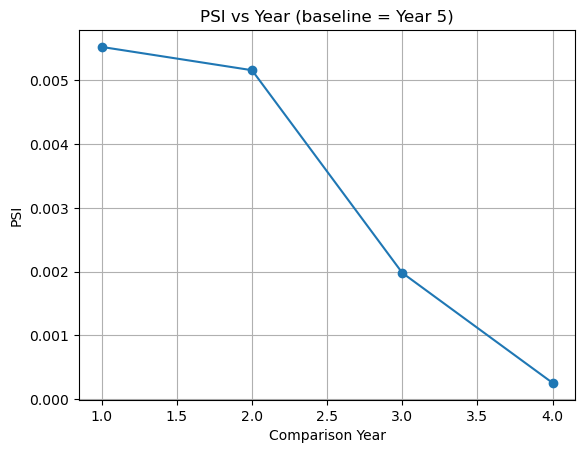

In [27]:
import matplotlib.pyplot as plt



# plot PSI values
plt.plot(df_psi['comparison_year'], df_psi['PSI'], marker='o')
plt.title("PSI vs Year (baseline = Year 5)")
plt.xlabel("Comparison Year")
plt.ylabel("PSI")
plt.grid(True)
plt.show()

See the yearly distribution.

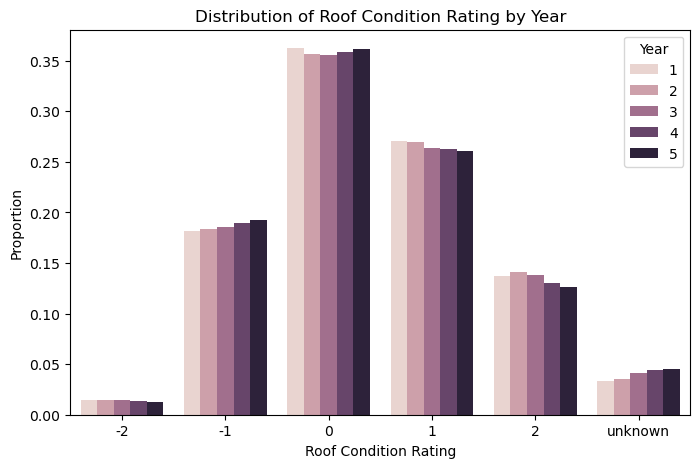

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# define your desired order
order = [-2, -1, 0, 1, 2, "unknown"]

plt.figure(figsize=(8,5))
sns.barplot(
    data=dist,
    x="cape_roof_condition_rating",
    y="proportion",
    hue="year_idx",
    order=order   # enforce order
)
plt.title("Distribution of Roof Condition Rating by Year")
plt.ylabel("Proportion")
plt.xlabel("Roof Condition Rating")
plt.legend(title="Year")
plt.show()

### Confusion matrix

This confusion matrix is compare Year 1, 2, 3, 4 versus Year 5 in terms of cape_roof_rating. \
We will save the confusion matrixs and the confusion matrix plot to the Excel.

In [29]:
import pandas as pd
from sklearn.metrics import confusion_matrix

def roof_confusion_matrices(df, time_col='cape_run_dt', id_col='pol_num', rating_col='cape_roof_condition_rating'):
    # 1. Convert run_dt to datetime
    df[time_col] = pd.to_datetime(df[time_col])

    # 2. Sort by policy + time
    df_sorted = df.sort_values([id_col, time_col])

    # 3. Assign year index within each policy
    df_sorted['year_idx'] = df_sorted.groupby(id_col).cumcount() + 1

    # 4. Pivot so each year becomes a column
    df_pivot = df_sorted.pivot(index=id_col, columns='year_idx', values=rating_col)
    df_pivot.columns = [f'Year{c}' for c in df_pivot.columns]

    # 5. Compute confusion matrices
    conf_matrices = {}
    for i in range(0, 4):  # Compare Year1 with Year2..5
        y_true = df_pivot['Year5'].dropna()
        y_pred = df_pivot[f'Year{i+1}'].dropna()

        # Align on common policies
        common_idx = y_true.index.intersection(y_pred.index)
        cm = confusion_matrix(y_true.loc[common_idx], y_pred.loc[common_idx])
        conf_matrices[f'Year5_vs_Year{i+1}'] = cm

    return conf_matrices, df_pivot

# ---- Example usage ----
conf_matrices, df_pivot = roof_confusion_matrices(df5_catch)




In [30]:
import io
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ---------- 1) Build confusion matrix with totals & % ----------
def add_total(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    df = pd.DataFrame(
        cm,
        index=pd.Index(labels, name="True"),
        columns=pd.Index(labels, name="Pred")
    )
    # Row totals
    df["Total"] = df.sum(axis=1)

    # Column totals
    total_row = df.sum(axis=0)
    total_row.name = "Total"
    df = pd.concat([df, pd.DataFrame([total_row])])

    # Grand total
    grand_total = int(total_row["Total"])

    # Percentages (ints) relative to grand total
    df["Total %"] = (df["Total"] / grand_total * 100).round(0).astype(int)
    pct_row = (df.loc["Total"] / grand_total * 100).round(0).astype(int)
    pct_row.name = "Total %"
    df = pd.concat([df, pd.DataFrame([pct_row])])

    return df

# ---------- 2) Plot augmented matrix (with totals & %) ----------
def plot_cm_augmented(df_aug, title, true_name="True", pred_name="Pred", figsize=(8, 7)):
    plt.figure(figsize=figsize)
    ax = sns.heatmap(df_aug, annot=True, fmt="d", cmap="Blues", cbar=False)

    # Put x-axis on top
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")

    ax.set_xlabel(f"Predicted ({pred_name})", labelpad=10)
    ax.set_ylabel(f"True ({true_name})", labelpad=10)
    ax.set_title(title, pad=40)

    plt.tight_layout()
    # Save figure to in-memory buffer (PNG)
    buf = io.BytesIO()
    plt.savefig(buf, format="png", dpi=180, bbox_inches="tight")
    plt.close()
    buf.seek(0)
    return buf  # BytesIO of the image





In [31]:

def save_confusion_matrices_to_excel(df_pivot, labels, out_path="cm_years_vs_year5.xlsx"):
    # Force xlsxwriter so insert_image works
    with pd.ExcelWriter(out_path, engine="xlsxwriter") as writer:
        workbook = writer.book
        bold = workbook.add_format({"bold": True})

        for i in range(1, 5):
            sheet_name = f"Year{i}_vs_Year5"
            try:
                # Align indices before building CM
                y_true = df_pivot[f"Year{i}"].dropna()
                y_pred = df_pivot["Year5"].dropna()
                common_idx = y_true.index.intersection(y_pred.index)
                y_t = y_true.loc[common_idx]
                y_p = y_pred.loc[common_idx]

                # Build augmented matrix
                df_aug = add_total(y_t, y_p, labels)

                # Create sheet + write title
                df_aug.to_excel(writer, sheet_name=sheet_name, startrow=2, startcol=0)
                ws = writer.sheets[sheet_name]
                ws.write(0, 0, f"Confusion Matrix: Year{i} vs Year5", bold)
                ws.write(1, 0, f"N = {int(df_aug.loc['Total','Total'])}")

                # Auto-size columns a bit
                n_cols_written = df_aug.shape[1] + 1  # +1 for index col
                for c in range(n_cols_written):
                    ws.set_column(c, c, 12)

                # Build figure buffer and insert it below the table
                img_buf = plot_cm_augmented(
                    df_aug=df_aug,
                    title=f"Confusion Matrix: Year{i} vs Year5",
                    true_name=f"Year{i}",
                    pred_name="Year5",
                    figsize=(8.5, 7.5),
                )
                start_row_for_image = df_aug.shape[0] + 5  # below table
                ws.insert_image(
                    start_row_for_image, 0,
                    f"{sheet_name}.png",
                    {"image_data": img_buf, "x_scale": 1.0, "y_scale": 1.0}
                )

            except KeyError as e:
                # If a Year{i} column is missing, write a note so the file still saves
                ws = writer.book.add_worksheet(sheet_name)
                ws.write(0, 0, f"Skipped: {e}", bold)
            except Exception as e:
                ws = writer.book.add_worksheet(sheet_name)
                ws.write(0, 0, f"Error generating this sheet: {e}", bold)

    print(f"Saved -> {out_path}")

In [32]:
labels = [-2, -1, 0, 1, 2, "unknown"]

for i in range(1, 5):
    y_true = df_pivot[f"Year{i}"].dropna()
    y_pred = df_pivot["Year5"].dropna()
    common_idx = y_true.index.intersection(y_pred.index)
    '''
    plot_confusion_matrix(
        y_true.loc[common_idx],
        y_pred.loc[common_idx],
        labels=labels,
        title=f"Confusion Matrix: Year{i} vs Year5",
        true_name=f"Year{i}",
        pred_name="Year5"
    )
    '''
save_confusion_matrices_to_excel(df_pivot, labels, out_path="v5_confusion_matrices.xlsx")

Saved -> v5_confusion_matrices.xlsx


### Year-to-Year confusion matrix

This confusion matrix is compare Year 1 versus Year 2, Year 2 versus Year 3 etc in terms of cape_roof_rating. \
We will save the confusion matrixs, the difference plot, and the confusion matrix plot to the Excel.

In [33]:
import io
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from io import BytesIO


def roof_confusion_matrices_year2year(df, time_col='cape_run_dt', id_col='pol_num', rating_col='cape_roof_condition_rating'):
    # 1. Convert run_dt to datetime
    df[time_col] = pd.to_datetime(df[time_col])

    # 2. Sort by policy + time
    df_sorted = df.sort_values([id_col, time_col])

    # 3. Assign year index within each policy
    df_sorted['year_idx'] = df_sorted.groupby(id_col).cumcount() + 1

    # 4. Pivot so each year becomes a column
    df_pivot = df_sorted.pivot(index=id_col, columns='year_idx', values=rating_col)
    df_pivot.columns = [f'Year{c}' for c in df_pivot.columns]

    # 5. Compute confusion matrices
    conf_matrices = {}
    for i in range(0, 4):  # Compare Year1 with Year2..5
        y_true = df_pivot[f'Year{i+2}'].dropna()
        y_pred = df_pivot[f'Year{i+1}'].dropna()

        # Align on common policies
        common_idx = y_true.index.intersection(y_pred.index)
        cm = confusion_matrix(y_true.loc[common_idx], y_pred.loc[common_idx])
        conf_matrices[f'Year{i+2}_vs_Year{i+1}'] = cm

    return conf_matrices, df_pivot

# ---- Example usage ----
conf_matrices, df_pivot = roof_confusion_matrices_year2year(df5_catch)


In [34]:

# ---------- 1) Build confusion matrix with totals & % ----------
def add_total(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    df = pd.DataFrame(
        cm,
        index=pd.Index(labels, name="True"),
        columns=pd.Index(labels, name="Pred")
    )
    # Row totals
    df["Total"] = df.sum(axis=1)

    # Column totals
    total_row = df.sum(axis=0)
    total_row.name = "Total"
    df = pd.concat([df, pd.DataFrame([total_row])])

    # Grand total
    grand_total = int(total_row["Total"])

    # Percentages (ints) relative to grand total
    df["Total %"] = (df["Total"] / grand_total * 100).round(0).astype(int)
    pct_row = (df.loc["Total"] / grand_total * 100).round(0).astype(int)
    pct_row.name = "Total %"
    df = pd.concat([df, pd.DataFrame([pct_row])])

    return df

# ---------- 2) Plot augmented matrix (with totals & %) ----------
def plot_cm_augmented(df_aug, title, true_name="True", pred_name="Pred", figsize=(8, 7)):
    plt.figure(figsize=figsize)
    ax = sns.heatmap(df_aug, annot=True, fmt="d", cmap="Blues", cbar=False)

    # Put x-axis on top
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")

    ax.set_xlabel(f"Predicted ({pred_name})", labelpad=10)
    ax.set_ylabel(f"True ({true_name})", labelpad=10)
    ax.set_title(title, pad=40)

    plt.tight_layout()
    # Save figure to in-memory buffer (PNG)
    buf = io.BytesIO()
    plt.savefig(buf, format="png", dpi=180, bbox_inches="tight")
    plt.close()
    buf.seek(0)
    return buf  # BytesIO of the image


def plot_year_to_year_diff_percent(
    y_true: pd.Series,
    y_pred: pd.Series,
    *,
    df_aug: pd.DataFrame,            # REQUIRED to get Total and exact diagonal
    labels,                          # your label list, e.g., [-2, -1, 0, 1, 2, "unknown"]
    unknown_label: str = "unknown",
    title: str = "Year-to-Year Difference (%)",
    xlabel: str = "Δ = Pred − True",
    ylabel: str = "Percentage",
    figsize=(7.5, 4.0),
) -> BytesIO:
    """
    Plot percentage distribution of Δ = pred - true with special handling:
      - both numeric -> pred - true
      - both unknown -> Δ = 0
      - one unknown, one numeric -> excluded from Δ bins (NaN), but kept in denominator

    Denominator is forced to df_aug.loc["Total", "Total"].
    The Δ=0 bin count is forced to the diagonal sum across `labels` (same_count).
    """
    # 1) Denominator and exact zero bin from your augmented CM
    total_count = int(df_aug.loc["Total", "Total"])
    same_count = int(sum(
        df_aug.loc[l, l] for l in labels
        if (l in df_aug.index) and (l in df_aug.columns)
    ))

    # 2) Build diffs with the rules above
    t_num = pd.to_numeric(y_true, errors="coerce")
    p_num = pd.to_numeric(y_pred, errors="coerce")

    both_numeric  = (~t_num.isna()) & (~p_num.isna())
    both_unknown  = (y_true == unknown_label) & (y_pred == unknown_label)
    unk_vs_num    = ((y_true == unknown_label) & (~p_num.isna())) | ((y_pred == unknown_label) & (~t_num.isna()))

    # start with NaNs
    diff = pd.Series(np.nan, index=y_true.index, dtype="float64")
    # numeric-numeric
    diff.loc[both_numeric] = (p_num[both_numeric] - t_num[both_numeric]).astype(float)
    # unknown-unknown -> 0 (will be overridden by same_count later)
    diff.loc[both_unknown] = 0.0
    # unknown-number stays NaN (excluded from bins)

    # 3) Raw counts from diffs (numeric bins only)
    counts = diff.dropna().value_counts().sort_index()

    # 4) Force Δ=0 to match same_count from CM diagonal
    # (Replace if exists; create if not.)
    zero_key = 0.0
    counts[zero_key] = same_count
    counts = counts.sort_index()

    # 5) Convert to percentages using your total_count denominator
    denom = max(total_count, 1)
    pct = (counts / denom * 100.0).round(2)

    # (Optional) Debug print
    # print("Δ counts (with forced zero bin):\n", counts)
    # print("Δ % (denominator = df_aug['Total','Total']):\n", pct)
    # print(f"same_count={same_count}, total_count={total_count}")

    # 6) Plot
    fig, ax = plt.subplots(figsize=figsize)

    if pct.empty:
        ax.text(0.5, 0.5, "No valid pairs for diff.", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
    else:
        x_vals = pct.index.to_numpy(dtype=float)
        y_vals = pct.to_numpy()

        ax.bar(x_vals, y_vals)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, max(5, y_vals.max() * 1.20))

        # integer ticks if diffs are integers
        if np.allclose(x_vals, np.round(x_vals)):
            xt = sorted(np.unique(x_vals))
            ax.set_xticks(xt)
            ax.set_xticklabels([str(int(v)) for v in xt])

        # Annotate
        for xv, yv in zip(x_vals, y_vals):
            ax.text(xv, yv + (ax.get_ylim()[1] * 0.01), f"{yv:.1f}%", ha="center", va="bottom", fontsize=9)

        ax.grid(axis="y", linestyle="--", alpha=0.35)

        # Add a small footer to make the denominator explicit
        ax.text(1.0, -0.18,
                f"N_total={total_count}; Δ=0 uses diagonal sum={same_count}; unknown↔number in denominator only",
                ha="right", va="center", transform=ax.transAxes, fontsize=9)

    buf = BytesIO()
    fig.tight_layout()
    fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return buf

def save_confusion_matrices_to_excel_year2year(df_pivot, labels, out_path="cm_years_vs_year5.xlsx"):
    # Force xlsxwriter so insert_image works
    with pd.ExcelWriter(out_path, engine="xlsxwriter") as writer:
        workbook = writer.book
        bold = workbook.add_format({"bold": True})

        for i in range(1, 5):
            sheet_name = f"Year{i}_vs_Year{i+1}"
            try:
                # Align indices before building CM
                y_true = df_pivot[f"Year{i}"].dropna()
                y_pred = df_pivot[f"Year{i+1}"].dropna()
                common_idx = y_true.index.intersection(y_pred.index)
                y_t = y_true.loc[common_idx]
                y_p = y_pred.loc[common_idx]

                # Build augmented matrix (your add_total already includes totals)
                df_aug = add_total(y_t, y_p, labels)

                # --- NEW: compute "remain the same" count ---
                same_count = sum(
                    df_aug.loc[l, l] for l in labels
                    if (l in df_aug.index) and (l in df_aug.columns)
                )
                total_count = int(df_aug.loc["Total", "Total"])
                same_pct = same_count / total_count if total_count > 0 else 0.0

                # Create sheet + write title and summary
                startrow_table, startcol_table = 4, 1
                df_aug.to_excel(writer, sheet_name=sheet_name, startrow=startrow_table, startcol=startcol_table)
                ws = writer.sheets[sheet_name]
                ws.write(0, 0, f"Confusion Matrix: Year{i} vs Year{i+1}", bold)
                ws.write(1, 0, f"N = {total_count}")
                ws.write(2, 0, f"{same_count} out of {total_count} policies remain the same ({same_pct:.2%})")
                ws.write(3, 5, f"Year{i+1}")
                ws.write(7, 0, f"Year{i}")
                # Auto-size columns a bit
                n_cols_written = df_aug.shape[1] + 1  # +1 for index col
                for c in range(n_cols_written):
                    ws.set_column(c, c, 12)


                
                # --- NEW: Year-to-Year difference percentage plot ---
                diff_title = f"Year-to-Year Difference (%): Year{i} → Year{i+1}"
                img_buf_diff = plot_year_to_year_diff_percent(
                    y_true=y_t,
                    y_pred=y_p,
                    df_aug=df_aug,
                    labels=labels,
                    unknown_label="unknown",
                    title=f"Year-to-Year Difference (%): Year{i} → Year{i+1}",
                    xlabel=f"Δ = Year{i+1} − Year{i}",
                    ylabel="Percentage",
                    figsize=(8.5, 3.8),
                )
                # Place it below the CM figure. A simple fixed offset works well.
                # start_row_for_diff = start_row_for_cm + 32  # push below the first image
                start_row_for_diff = startrow_table + df_aug.shape[0] + 1
                ws.insert_image(
                    start_row_for_diff, 0,
                    f"{sheet_name}_diff.png",
                    {"image_data": img_buf_diff, "x_scale": 1.0, "y_scale": 1.0}
                )
                # --- Existing CM figure ---
                img_buf_cm = plot_cm_augmented(
                    df_aug=df_aug,
                    title=f"Confusion Matrix: Year{i} vs Year{i+1}",
                    true_name=f"Year{i}",
                    pred_name=f"Year{i+1}",
                    figsize=(8.5, 7.5),
                )

                start_row_for_cm = start_row_for_diff + 20  # push below first image
                ws.insert_image(
                    start_row_for_cm, 0,
                    f"{sheet_name}_cm.png",
                    {"image_data": img_buf_cm, "x_scale": 1.0, "y_scale": 1.0}
                )
            except KeyError as e:
                ws = writer.book.add_worksheet(sheet_name)
                ws.write(0, 0, f"Skipped: {e}", bold)
            except Exception as e:
                ws = writer.book.add_worksheet(sheet_name)
                ws.write(0, 0, f"Error generating this sheet: {e}", bold)

    print(f"Saved -> {out_path}")



In [35]:
labels = [-2, -1, 0, 1, 2, "unknown"]

for i in range(0, 4):
    y_true = df_pivot[f"Year{i+1}"].dropna()
    y_pred = df_pivot[f"Year{i+2}"].dropna()
    common_idx = y_true.index.intersection(y_pred.index)
    '''
    plot_confusion_matrix(
        y_true.loc[common_idx],
        y_pred.loc[common_idx],
        labels=labels,
        title=f"Confusion Matrix: Year{i} vs Year5",
        true_name=f"Year{i}",
        pred_name="Year5"
    )
    '''
# save_confusion_matrices_to_excel_year2year(df_pivot, labels, out_path="v4_confusion_matrices_year2year.xlsx")
save_confusion_matrices_to_excel_year2year(df_pivot, labels, out_path="v5_confusion_matrices_year2year.xlsx")

Saved -> v5_confusion_matrices_year2year.xlsx
